<a href="https://colab.research.google.com/github/asmi2604/delhivery-feature-engineering/blob/main/delhivery_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delhivery Logistics — Feature Engineering & EDA

**Dataset:** Delhivery shipment route data  
**Goal:** Clean, aggregate, engineer features, run hypothesis tests, handle outliers, encode, and normalize — so the data is ready for downstream modelling.

---

## 0. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Load Data

In [3]:
# If running on Colab, upload the CSV first:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('delhivery_data.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (21864, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9.000,2018-09-20 04:27:55,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18.000,2018-09-20 04:17:55,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27.000,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286


## 2. Basic Structure & Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21864 entries, 0 to 21863
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   data                            21864 non-null  object 
 1   trip_creation_time              21864 non-null  object 
 2   route_schedule_uuid             21864 non-null  object 
 3   route_type                      21864 non-null  object 
 4   trip_uuid                       21864 non-null  object 
 5   source_center                   21864 non-null  object 
 6   source_name                     21802 non-null  object 
 7   destination_center              21863 non-null  object 
 8   destination_name                21814 non-null  object 
 9   od_start_time                   21863 non-null  object 
 10  od_end_time                     21863 non-null  object 
 11  start_scan_to_end_scan          21863 non-null  float64
 12  is_cutoff                       

In [5]:
df.describe(include='all')

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,21864,21864,21864,21864,21864,21864,21802,21863,21814,21863,21863,21863.000,21863,21863.000,21863,21863.000,21863.000,21863.000,21863.000,21863.000,21863.000,21863.000,21863.000,21863.000
unique,2,2292,1021,2,2292,1098,1092,1088,1081,4174,4174,NaN,2,NaN,19538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,training,2018-09-28 05:23:15.359220,thanos::sroute:e2f5faaa-455a-494b-a501-549c3e3...,FTL,trip-153811219535896559,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-10-03 04:55:30.039225,2018-10-05 11:15:01.115906,NaN,True,NaN,2018-09-17 23:27:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,15652,101,338,14878,101,3680,3680,1998,1998,79,79,NaN,17732,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,874.971,NaN,214.884,NaN,215.985,380.292,198.128,263.405,2.075,35.301,18.294,22.517,2.207
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,965.997,NaN,328.430,NaN,328.621,555.632,294.721,403.067,1.387,46.345,13.437,15.934,7.015
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000,NaN,9.000,NaN,9.000,9.000,6.000,9.102,0.250,-26.000,0.000,0.000,-1.857
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149.000,NaN,22.000,NaN,23.070,49.000,26.000,29.016,1.597,19.000,11.000,11.893,1.350
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,405.000,NaN,54.000,NaN,55.316,119.000,59.000,71.716,1.851,28.000,17.000,23.396,1.688
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1364.000,NaN,242.000,NaN,243.585,449.000,225.000,298.887,2.204,40.000,22.000,27.570,2.250


In [6]:
# Convert datetime columns
datetime_cols = ['trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Convert route_type to category
df['route_type'] = df['route_type'].astype('category')
df['is_cutoff'] = df['is_cutoff'].astype('category')

print('Dtypes after conversion:')
print(df.dtypes)

Dtypes after conversion:
data                                      object
trip_creation_time                datetime64[ns]
route_schedule_uuid                       object
route_type                              category
trip_uuid                                 object
source_center                             object
source_name                               object
destination_center                        object
destination_name                          object
od_start_time                     datetime64[ns]
od_end_time                       datetime64[ns]
start_scan_to_end_scan                   float64
is_cutoff                               category
cutoff_factor                            float64
cutoff_timestamp                  datetime64[ns]
actual_distance_to_destination           float64
actual_time                              float64
osrm_time                                float64
osrm_distance                            float64
factor                                   flo

## 3. Missing Value Analysis

                                Missing Count  Missing %
cutoff_timestamp                          565      2.584
source_name                                62      0.284
destination_name                           50      0.229
destination_center                          1      0.005
od_end_time                                 1      0.005
od_start_time                               1      0.005
start_scan_to_end_scan                      1      0.005
is_cutoff                                   1      0.005
cutoff_factor                               1      0.005
actual_distance_to_destination              1      0.005
actual_time                                 1      0.005
osrm_time                                   1      0.005
osrm_distance                               1      0.005
factor                                      1      0.005
segment_actual_time                         1      0.005
segment_osrm_time                           1      0.005
segment_osrm_distance          

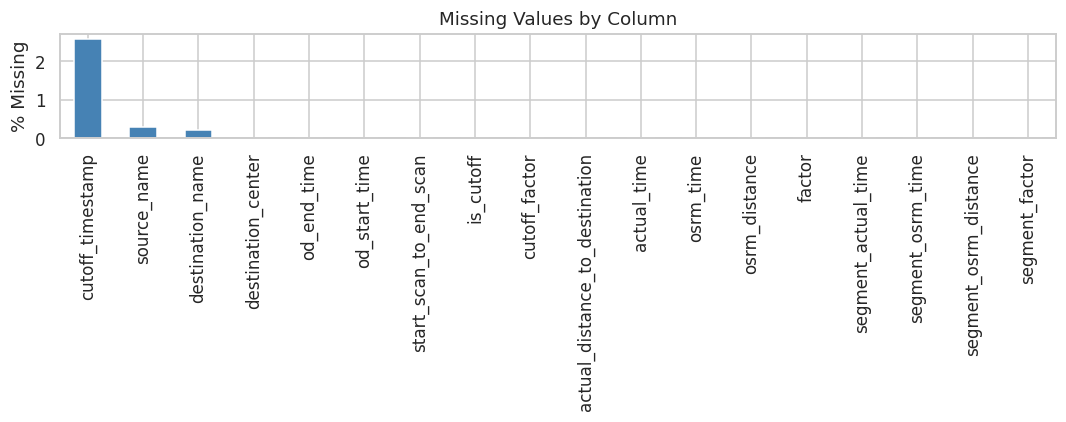

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

# Visualise
if not missing_df.empty:
    missing_df['Missing %'].plot(kind='bar', figsize=(10, 4), color='steelblue', edgecolor='white')
    plt.title('Missing Values by Column')
    plt.ylabel('% Missing')
    plt.tight_layout()
    plt.show()

In [8]:
# Handle missing values
# Numeric columns: fill with median
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical / object: fill with mode
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing after treatment:', df.isnull().sum().sum())

Missing after treatment: 567


## 4. Feature Engineering from Name Columns & Datetime

In [9]:
# ── Helper: parse "City_PlaceCode_Type (State)" ──────────────────────────────
def parse_location(series, prefix):
    """Extracts city, place_code, type, and state from Delhivery location strings."""
    # State is inside parentheses
    state = series.str.extract(r'\(([^)]+)\)')[0]
    # Remove the state part
    core = series.str.replace(r'\s*\([^)]+\)', '', regex=True).str.strip()
    parts = core.str.split('_', expand=True)
    result = pd.DataFrame()
    result[f'{prefix}_city']       = parts[0]
    result[f'{prefix}_place_code'] = parts[1] if parts.shape[1] > 1 else np.nan
    result[f'{prefix}_type']       = parts[2] if parts.shape[1] > 2 else np.nan
    result[f'{prefix}_state']      = state
    return result

src_features  = parse_location(df['source_name'],      'src')
dest_features = parse_location(df['destination_name'], 'dest')

df = pd.concat([df, src_features, dest_features], axis=1)
print('Source/Dest features added.')
df[['source_name', 'src_city', 'src_state', 'destination_name', 'dest_city', 'dest_state']].head(3)

Source/Dest features added.


,source_name,src_city,src_state,destination_name,dest_city,dest_state
0,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
1,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
2,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat


In [10]:
# ── Datetime features from trip_creation_time ─────────────────────────────────
df['trip_year']    = df['trip_creation_time'].dt.year
df['trip_month']   = df['trip_creation_time'].dt.month
df['trip_day']     = df['trip_creation_time'].dt.day
df['trip_hour']    = df['trip_creation_time'].dt.hour
df['trip_weekday'] = df['trip_creation_time'].dt.day_name()

print('Datetime features added.')
df[['trip_creation_time','trip_year','trip_month','trip_day','trip_hour','trip_weekday']].head(3)

Datetime features added.


,trip_creation_time,trip_year,trip_month,trip_day,trip_hour,trip_weekday
0,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday
1,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday
2,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday


In [11]:
# ── OD time difference (minutes) ──────────────────────────────────────────────
df['od_time_diff_min'] = (
    df['od_end_time'] - df['od_start_time']
).dt.total_seconds() / 60

# Drop originals
df.drop(columns=['od_start_time', 'od_end_time'], inplace=True)
print('od_time_diff_min created; originals dropped.')

od_time_diff_min created; originals dropped.


## 5. Row Merging / Aggregation

Each delivery leg is a separate row. We aggregate in two steps:
1. By `(trip_uuid, source_center, destination_center)` to collapse duplicate leg rows.
2. By `trip_uuid` to get one row per trip.

In [12]:
# ── Step 1: Group by trip + OD pair ───────────────────────────────────────────
agg_od = {
    'actual_time':              'sum',
    'osrm_time':                'sum',
    'osrm_distance':            'sum',
    'actual_distance_to_destination': 'first',
    'start_scan_to_end_scan':   'first',
    'od_time_diff_min':         'first',
    'segment_actual_time':      'sum',
    'segment_osrm_time':        'sum',
    'segment_osrm_distance':    'sum',
    'factor':                   'mean',
    'segment_factor':           'mean',
    'route_type':               'first',
    'trip_creation_time':       'first',
    'trip_year':                'first',
    'trip_month':               'first',
    'trip_day':                 'first',
    'trip_hour':                'first',
    'trip_weekday':             'first',
    'src_city':                 'first',
    'src_state':                'first',
    'dest_city':                'first',
    'dest_state':               'first',
    'is_cutoff':                'first',
}

df_od = df.groupby(['trip_uuid', 'source_center', 'destination_center']).agg(agg_od).reset_index()
print('After OD groupby:', df_od.shape)

After OD groupby: (4175, 26)


In [13]:
# ── Step 2: Group by trip_uuid only ───────────────────────────────────────────
agg_trip = {
    'actual_time':              'sum',
    'osrm_time':                'sum',
    'osrm_distance':            'sum',
    'actual_distance_to_destination': 'first',
    'start_scan_to_end_scan':   'first',
    'od_time_diff_min':         'sum',
    'segment_actual_time':      'sum',
    'segment_osrm_time':        'sum',
    'segment_osrm_distance':    'sum',
    'factor':                   'mean',
    'segment_factor':           'mean',
    'route_type':               'first',
    'trip_year':                'first',
    'trip_month':               'first',
    'trip_day':                 'first',
    'trip_hour':                'first',
    'trip_weekday':             'first',
    'src_city':                 'first',
    'src_state':                'first',
    'dest_city':                'first',
    'dest_state':               'first',
    'is_cutoff':                'first',
}

df_trip = df_od.groupby('trip_uuid').agg(agg_trip).reset_index()
print('After trip_uuid groupby:', df_trip.shape)
df_trip.head(3)

After trip_uuid groupby: (2292, 23)


,trip_uuid,actual_time,osrm_time,osrm_distance,actual_distance_to_destination,start_scan_to_end_scan,od_time_diff_min,segment_actual_time,segment_osrm_time,segment_osrm_distance,factor,segment_factor,route_type,trip_year,trip_month,trip_day,trip_hour,trip_weekday,src_city,src_state,dest_city,dest_state,is_cutoff
0,trip-153671079956500691,35.000,16.000,19.961,9.410,49.000,49.333,23.000,14.000,16.086,2.188,1.667,Carting,2018,9,12,0,Wednesday,Delhi,Delhi,Delhi,Delhi,True
1,trip-153671110078355292,17.000,9.000,10.816,9.397,38.000,38.501,17.000,9.000,10.816,1.889,1.889,Carting,2018,9,12,0,Wednesday,FBD,Haryana,Faridabad,Haryana,False
2,trip-153671191949943656,491.000,233.000,268.379,23.364,86.000,290.662,252.000,132.000,140.562,2.011,1.954,FTL,2018,9,12,0,Wednesday,Narsinghpur,Madhya Pradesh,Gadarwara,Madhya Pradesh,True


## 6. EDA — Distributions & Visual Analysis

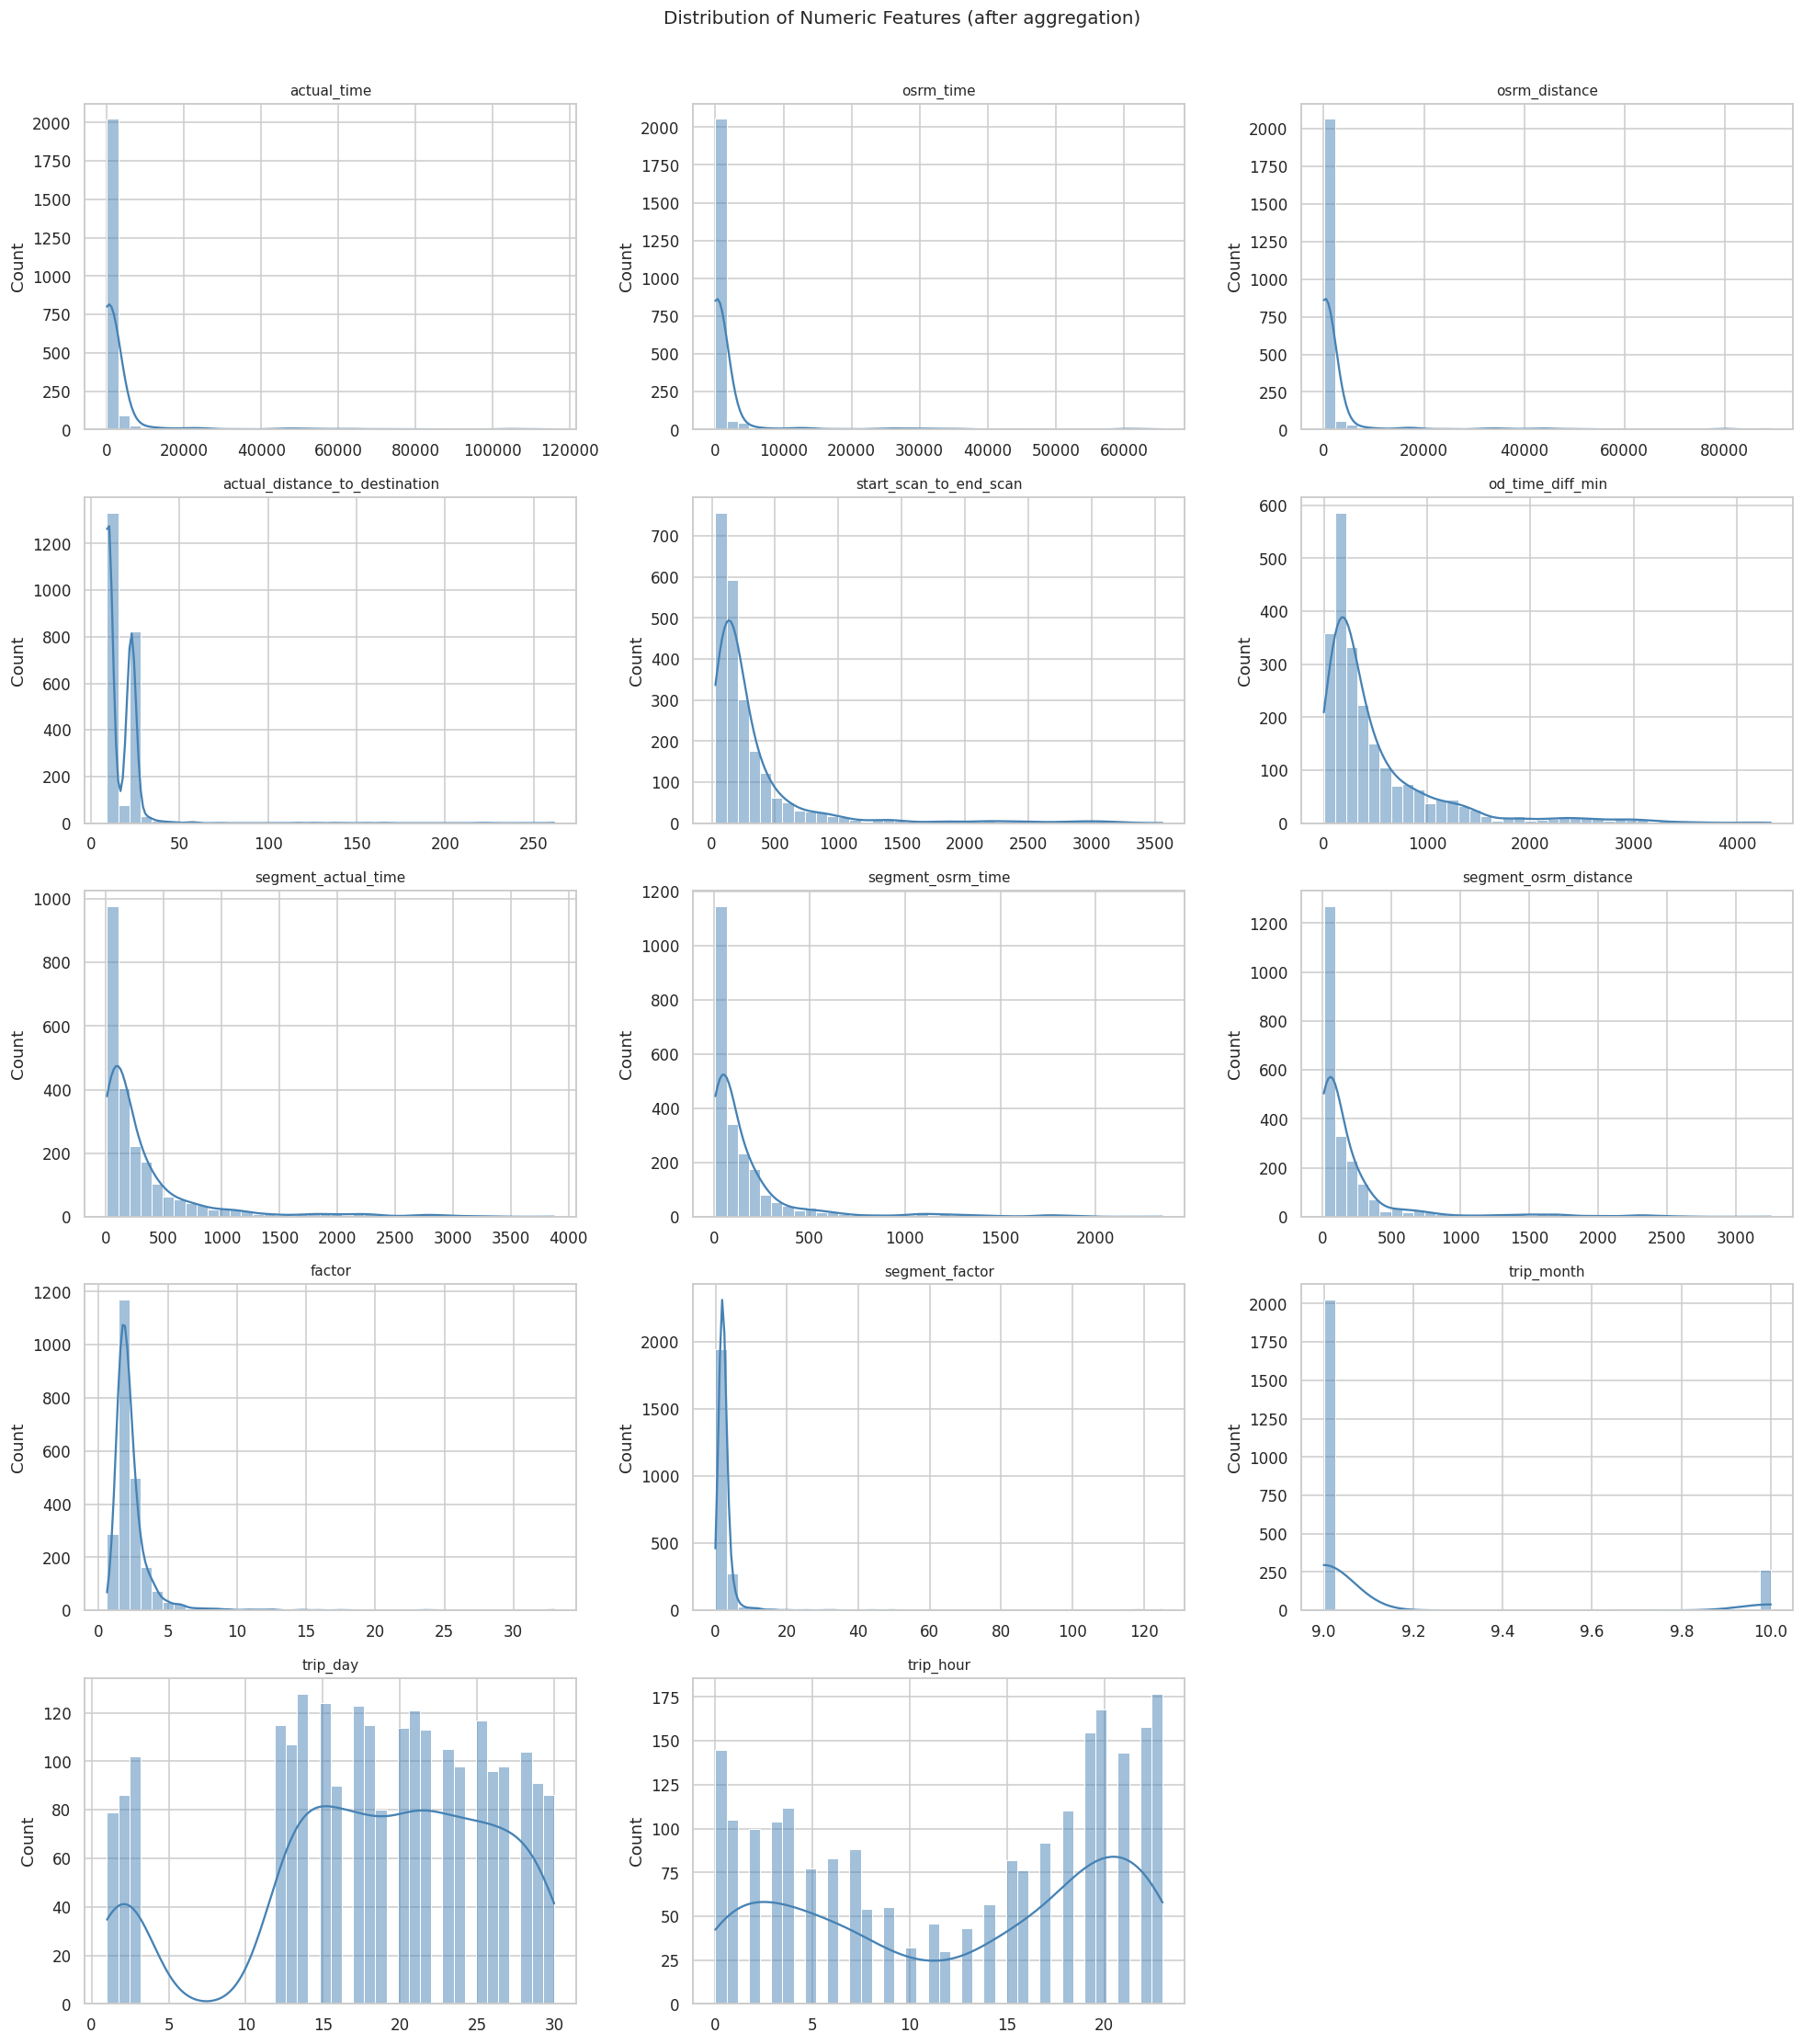

In [14]:
# Distribution plots for all numeric columns
numeric_cols = df_trip.select_dtypes(include=np.number).columns.drop('trip_year', errors='ignore').tolist()

n = len(numeric_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_trip[col].dropna(), ax=axes[i], kde=True, color='steelblue', bins=40)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Features (after aggregation)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

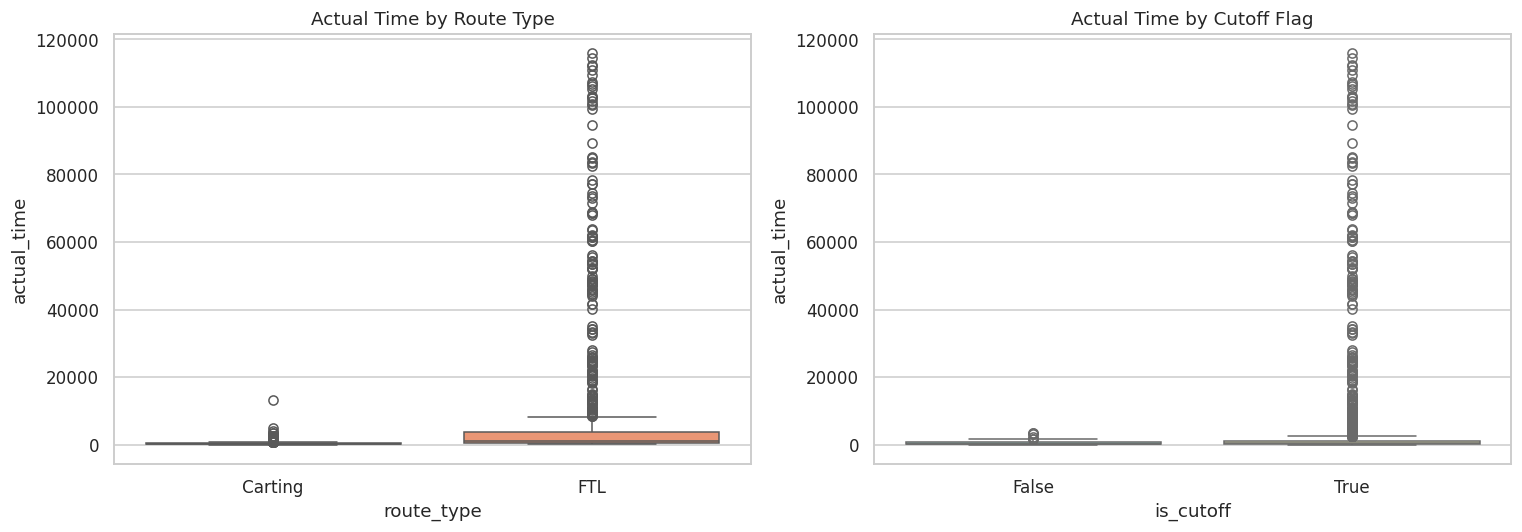

In [15]:
# Boxplots for categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_trip, x='route_type', y='actual_time', ax=axes[0], palette='Set2')
axes[0].set_title('Actual Time by Route Type')

sns.boxplot(data=df_trip, x='is_cutoff', y='actual_time', ax=axes[1], palette='Set3')
axes[1].set_title('Actual Time by Cutoff Flag')

plt.tight_layout()
plt.show()

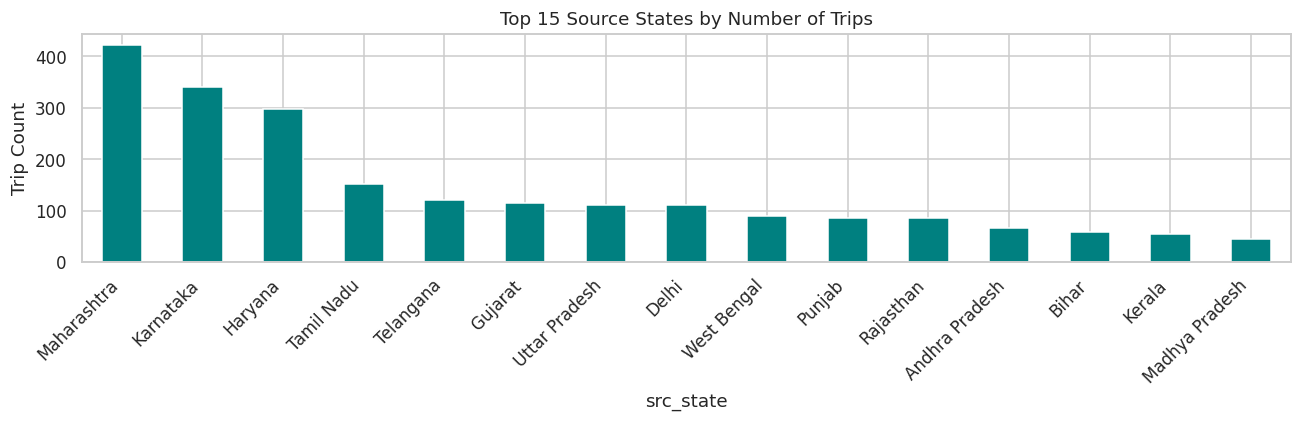

In [16]:
# Trips by state (source)
top_src_states = df_trip['src_state'].value_counts().head(15)
top_src_states.plot(kind='bar', figsize=(12, 4), color='teal', edgecolor='white')
plt.title('Top 15 Source States by Number of Trips')
plt.ylabel('Trip Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

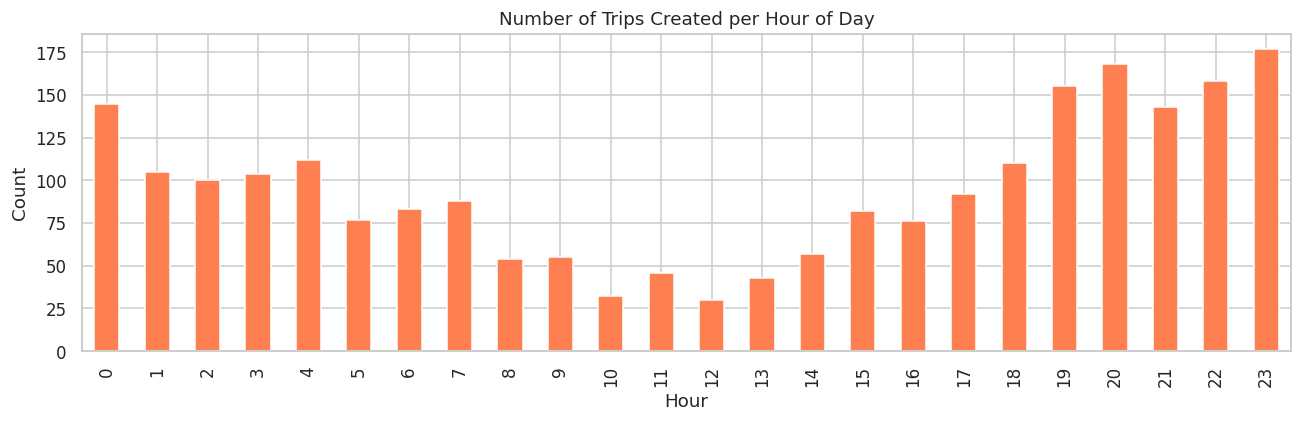

In [17]:
# Trips by hour
df_trip['trip_hour'].value_counts().sort_index().plot(
    kind='bar', figsize=(12, 4), color='coral', edgecolor='white'
)
plt.title('Number of Trips Created per Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [18]:
# Busiest corridors (src_state -> dest_state)
df_trip['corridor'] = df_trip['src_state'] + ' → ' + df_trip['dest_state']
corridor_stats = df_trip.groupby('corridor').agg(
    trip_count=('trip_uuid', 'count'),
    avg_distance=('osrm_distance', 'mean'),
    avg_time=('actual_time', 'mean')
).sort_values('trip_count', ascending=False).head(10)

print('Top 10 Busiest Corridors:')
print(corridor_stats.to_string())

Top 10 Busiest Corridors:
                               trip_count  avg_distance  avg_time
corridor                                                         
Maharashtra → Maharashtra             389       682.412  1066.591
Karnataka → Karnataka                 325       239.918   406.609
Tamil Nadu → Tamil Nadu               146       271.717   428.664
Haryana → Haryana                     121       319.950   549.140
Gujarat → Gujarat                     107      1089.638  1525.327
Telangana → Telangana                 104       249.146   415.519
West Bengal → West Bengal              84       280.168   654.369
Uttar Pradesh → Uttar Pradesh          81       360.031   770.074
Rajasthan → Rajasthan                  77       816.422  1326.545
Punjab → Punjab                        70       480.553   776.629


## 7. Time Feature Comparison & Hypothesis Testing

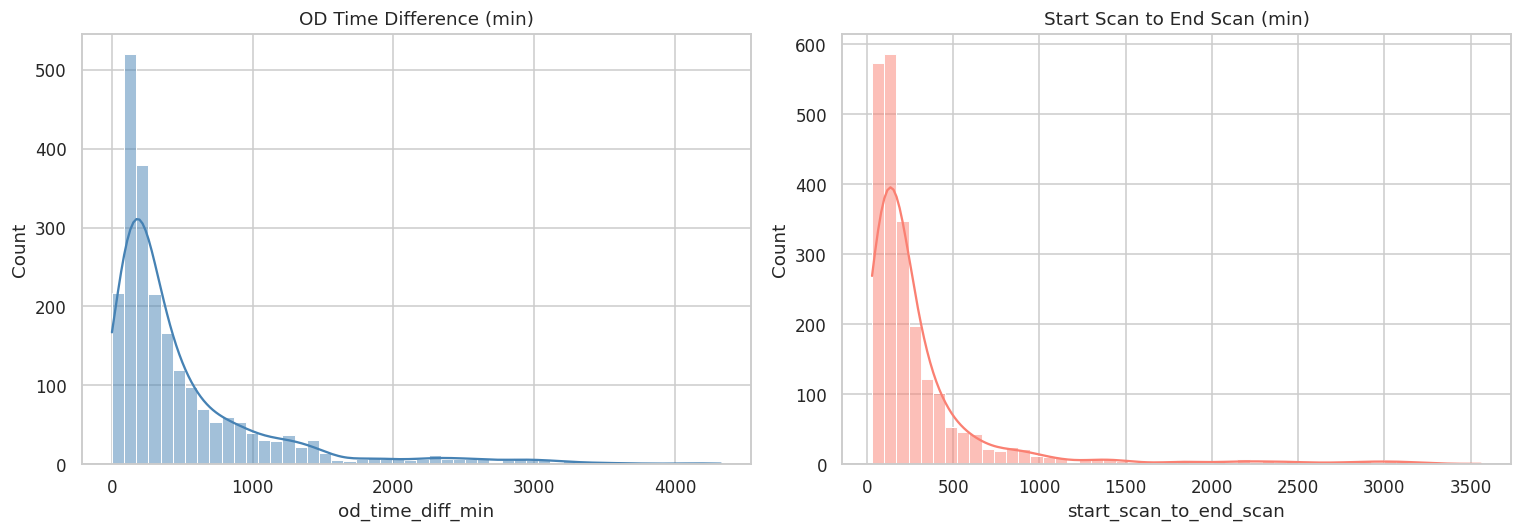

Mann-Whitney U — od_time_diff vs scan_time | stat=3350886.00, p=8.7886e-59
Interpretation: Significant difference


In [19]:
# ── 7a. od_time_diff_min vs start_scan_to_end_scan ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_trip['od_time_diff_min'].dropna(), bins=50, kde=True, ax=axes[0], color='steelblue', label='OD Time Diff')
sns.histplot(df_trip['start_scan_to_end_scan'].dropna(), bins=50, kde=True, ax=axes[1], color='salmon', label='Scan to Scan')
axes[0].set_title('OD Time Difference (min)')
axes[1].set_title('Start Scan to End Scan (min)')
plt.tight_layout()
plt.show()

# Wilcoxon / Mann-Whitney (not assuming normality)
a = df_trip['od_time_diff_min'].dropna()
b = df_trip['start_scan_to_end_scan'].dropna()
stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
print(f'Mann-Whitney U — od_time_diff vs scan_time | stat={stat:.2f}, p={p:.4e}')
print('Interpretation:', 'Significant difference' if p < 0.05 else 'No significant difference')

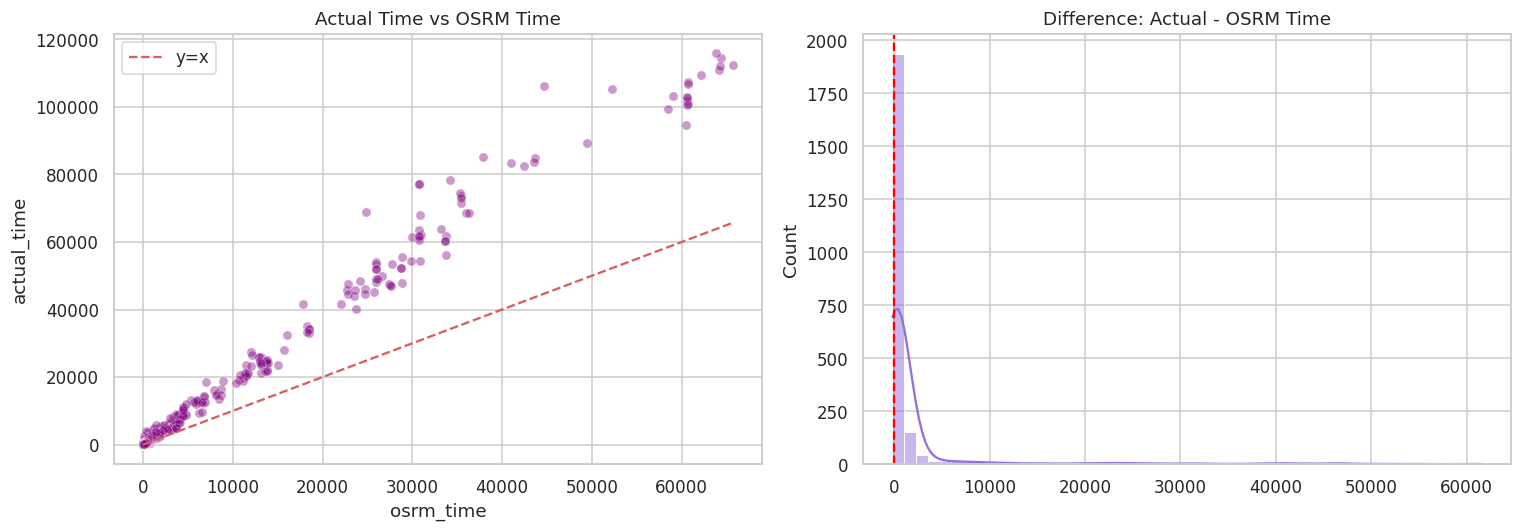

Wilcoxon — actual_time vs osrm_time | stat=6208.00, p=0.0000e+00
Interpretation: Significant difference


In [20]:
# ── 7b. actual_time vs osrm_time ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_trip.sample(min(5000, len(df_trip))), x='osrm_time', y='actual_time',
                alpha=0.4, ax=axes[0], color='purple')
axes[0].plot([0, df_trip['osrm_time'].max()], [0, df_trip['osrm_time'].max()], 'r--', label='y=x')
axes[0].set_title('Actual Time vs OSRM Time')
axes[0].legend()

diff_at_osrm = df_trip['actual_time'] - df_trip['osrm_time']
sns.histplot(diff_at_osrm.dropna(), bins=50, kde=True, ax=axes[1], color='mediumpurple')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Difference: Actual - OSRM Time')
plt.tight_layout()
plt.show()

stat, p = stats.wilcoxon(df_trip['actual_time'].dropna()[:5000],
                         df_trip['osrm_time'].dropna()[:5000])
print(f'Wilcoxon — actual_time vs osrm_time | stat={stat:.2f}, p={p:.4e}')
print('Interpretation:', 'Significant difference' if p < 0.05 else 'No significant difference')

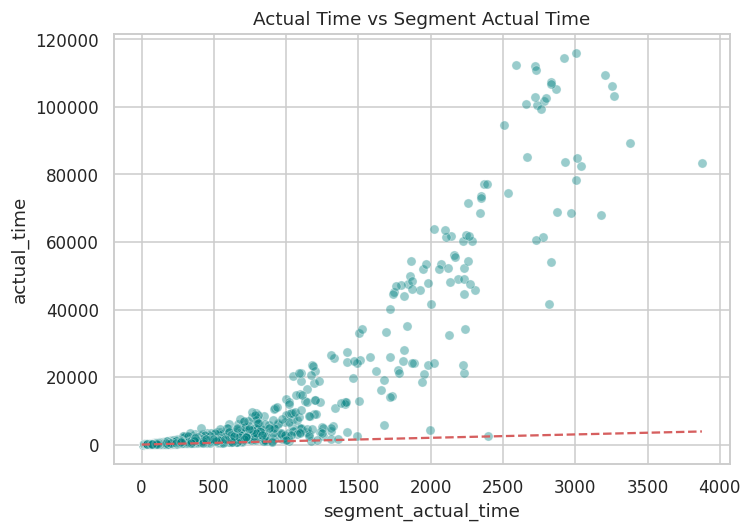

Wilcoxon — actual_time vs segment_actual_time | stat=0.00, p=0.0000e+00
Interpretation: Significant difference


In [21]:
# ── 7c. actual_time vs segment_actual_time ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sample = df_trip.sample(min(5000, len(df_trip)))
sns.scatterplot(data=sample, x='segment_actual_time', y='actual_time', alpha=0.4, color='teal', ax=ax)
ax.plot([0, sample['segment_actual_time'].max()], [0, sample['segment_actual_time'].max()], 'r--')
ax.set_title('Actual Time vs Segment Actual Time')
plt.tight_layout()
plt.show()

stat, p = stats.wilcoxon(df_trip['actual_time'].dropna()[:5000],
                         df_trip['segment_actual_time'].dropna()[:5000])
print(f'Wilcoxon — actual_time vs segment_actual_time | stat={stat:.2f}, p={p:.4e}')
print('Interpretation:', 'Significant difference' if p < 0.05 else 'No significant difference')

Wilcoxon — osrm_distance vs segment_osrm_distance | stat=510.00, p=0.0000e+00
Interpretation: Significant difference


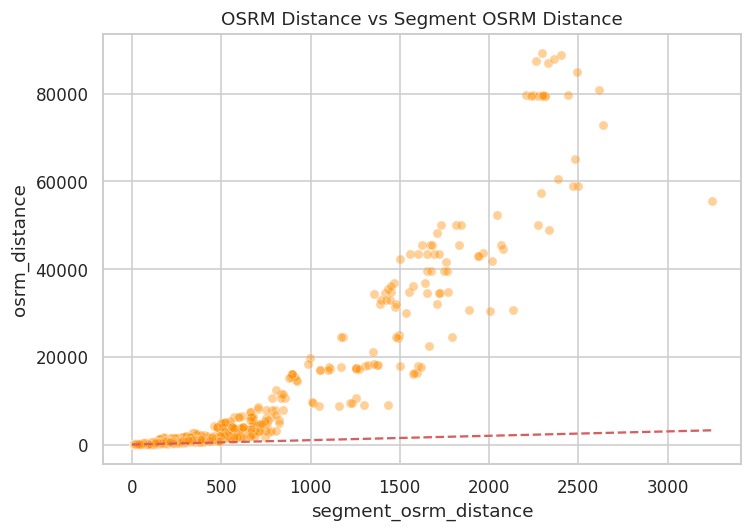

In [22]:
# ── 7d. osrm_distance vs segment_osrm_distance ───────────────────────────────
stat, p = stats.wilcoxon(df_trip['osrm_distance'].dropna()[:5000],
                         df_trip['segment_osrm_distance'].dropna()[:5000])
print(f'Wilcoxon — osrm_distance vs segment_osrm_distance | stat={stat:.2f}, p={p:.4e}')
print('Interpretation:', 'Significant difference' if p < 0.05 else 'No significant difference')

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=sample, x='segment_osrm_distance', y='osrm_distance', alpha=0.4, color='darkorange', ax=ax)
ax.plot([0, sample['segment_osrm_distance'].max()], [0, sample['segment_osrm_distance'].max()], 'r--')
ax.set_title('OSRM Distance vs Segment OSRM Distance')
plt.tight_layout()
plt.show()

In [23]:
# ── 7e. osrm_time vs segment_osrm_time ───────────────────────────────────────
stat, p = stats.wilcoxon(df_trip['osrm_time'].dropna()[:5000],
                         df_trip['segment_osrm_time'].dropna()[:5000])
print(f'Wilcoxon — osrm_time vs segment_osrm_time | stat={stat:.2f}, p={p:.4e}')
print('Interpretation:', 'Significant difference' if p < 0.05 else 'No significant difference')

Wilcoxon — osrm_time vs segment_osrm_time | stat=839.00, p=0.0000e+00
Interpretation: Significant difference


## 8. Outlier Detection & Treatment

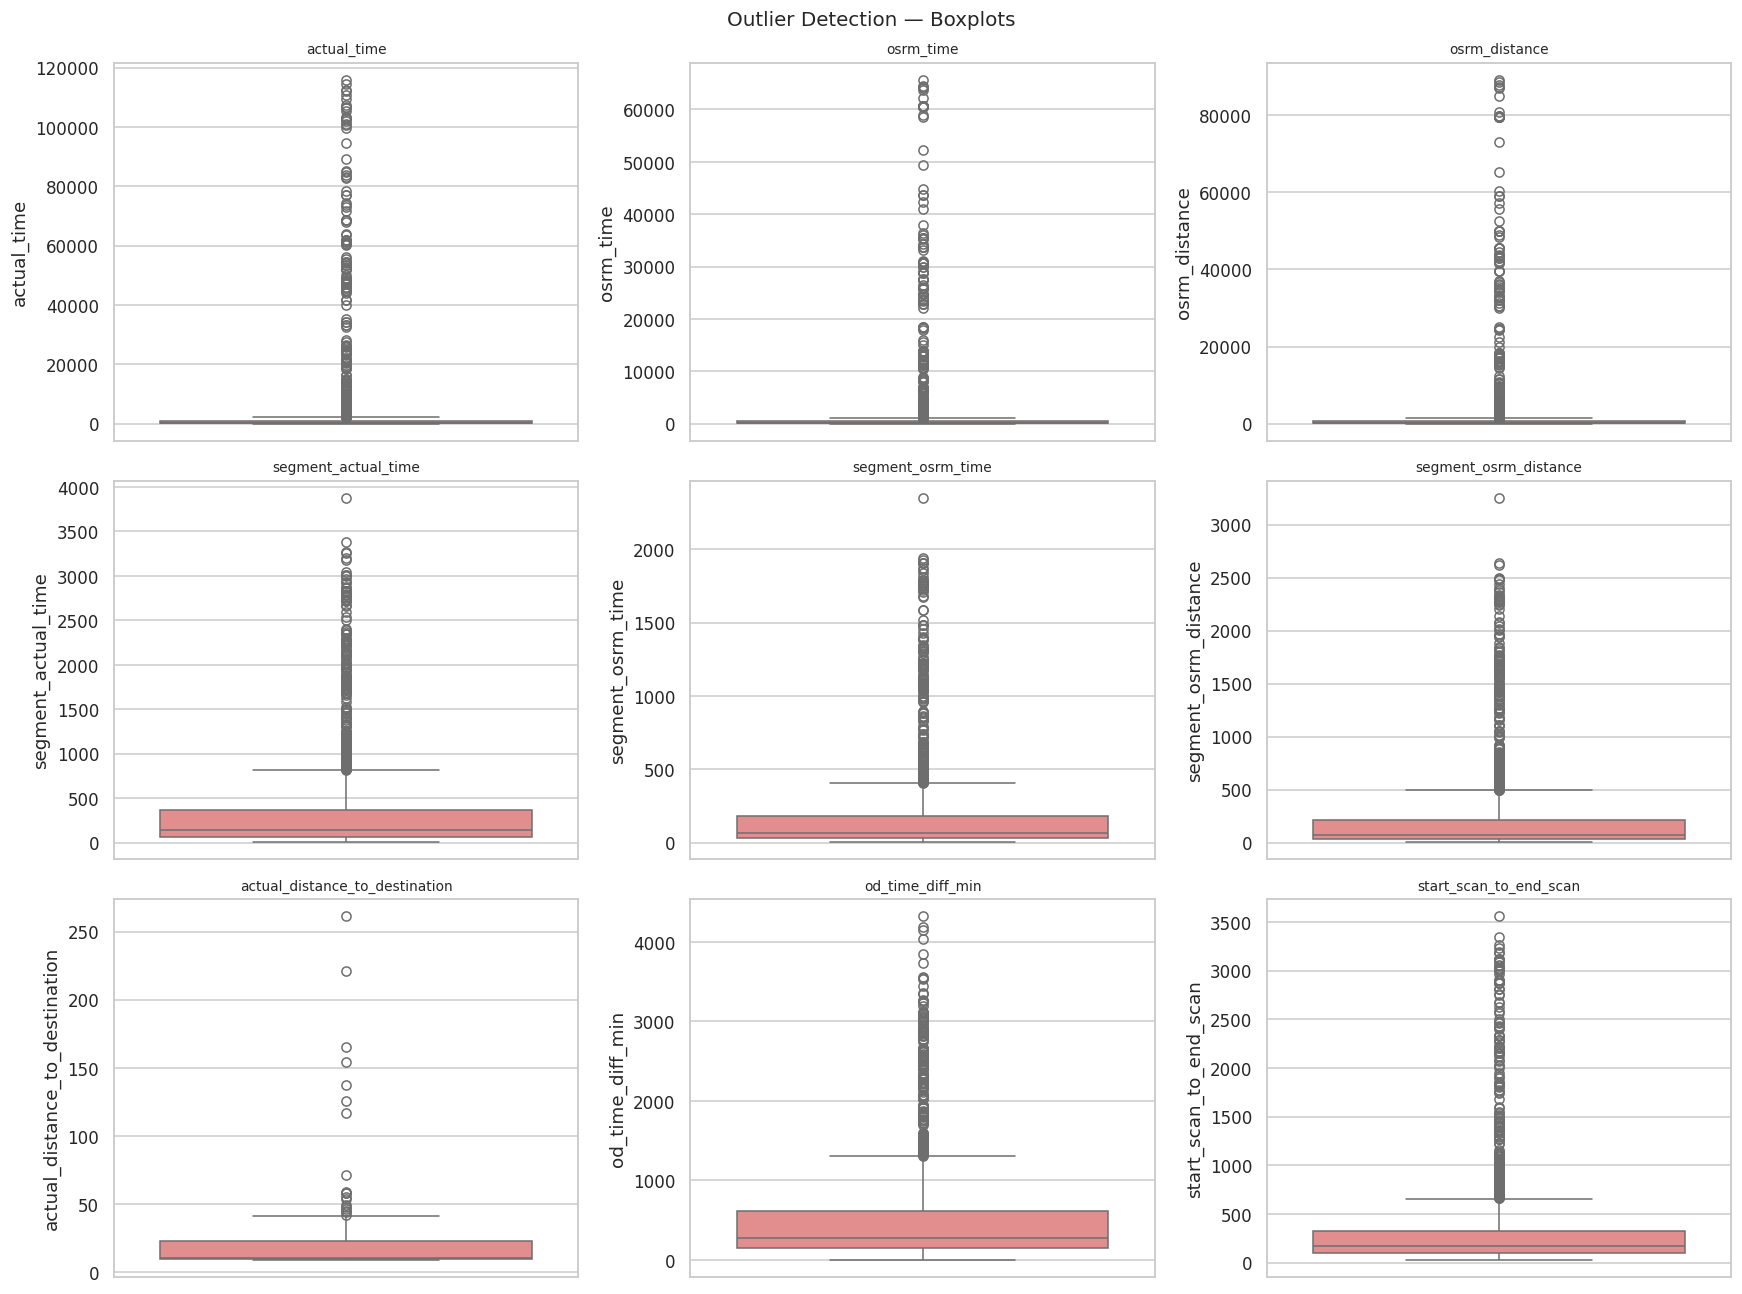

In [24]:
# Boxplots to visually identify outliers
num_features = [
    'actual_time', 'osrm_time', 'osrm_distance',
    'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance',
    'actual_distance_to_destination', 'od_time_diff_min', 'start_scan_to_end_scan'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=df_trip[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Outlier Detection — Boxplots', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# IQR-based outlier capping (Winsorization)
def cap_outliers_iqr(df, cols):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower, upper)
        print(f'{col}: {before} outliers capped → [{lower:.2f}, {upper:.2f}]')
    return df

df_clean = cap_outliers_iqr(df_trip, num_features)
print('\nOutlier treatment complete.')

actual_time: 312 outliers capped → [-1194.00, 2350.00]
osrm_time: 293 outliers capped → [-605.38, 1171.62]
osrm_distance: 306 outliers capped → [-744.18, 1413.39]
segment_actual_time: 230 outliers capped → [-388.50, 815.50]
segment_osrm_time: 229 outliers capped → [-196.88, 408.12]
segment_osrm_distance: 236 outliers capped → [-245.43, 494.03]
actual_distance_to_destination: 19 outliers capped → [-10.15, 42.02]
od_time_diff_min: 196 outliers capped → [-554.71, 1307.72]
start_scan_to_end_scan: 222 outliers capped → [-235.88, 659.12]

Outlier treatment complete.


## 9. Correlation Heatmap

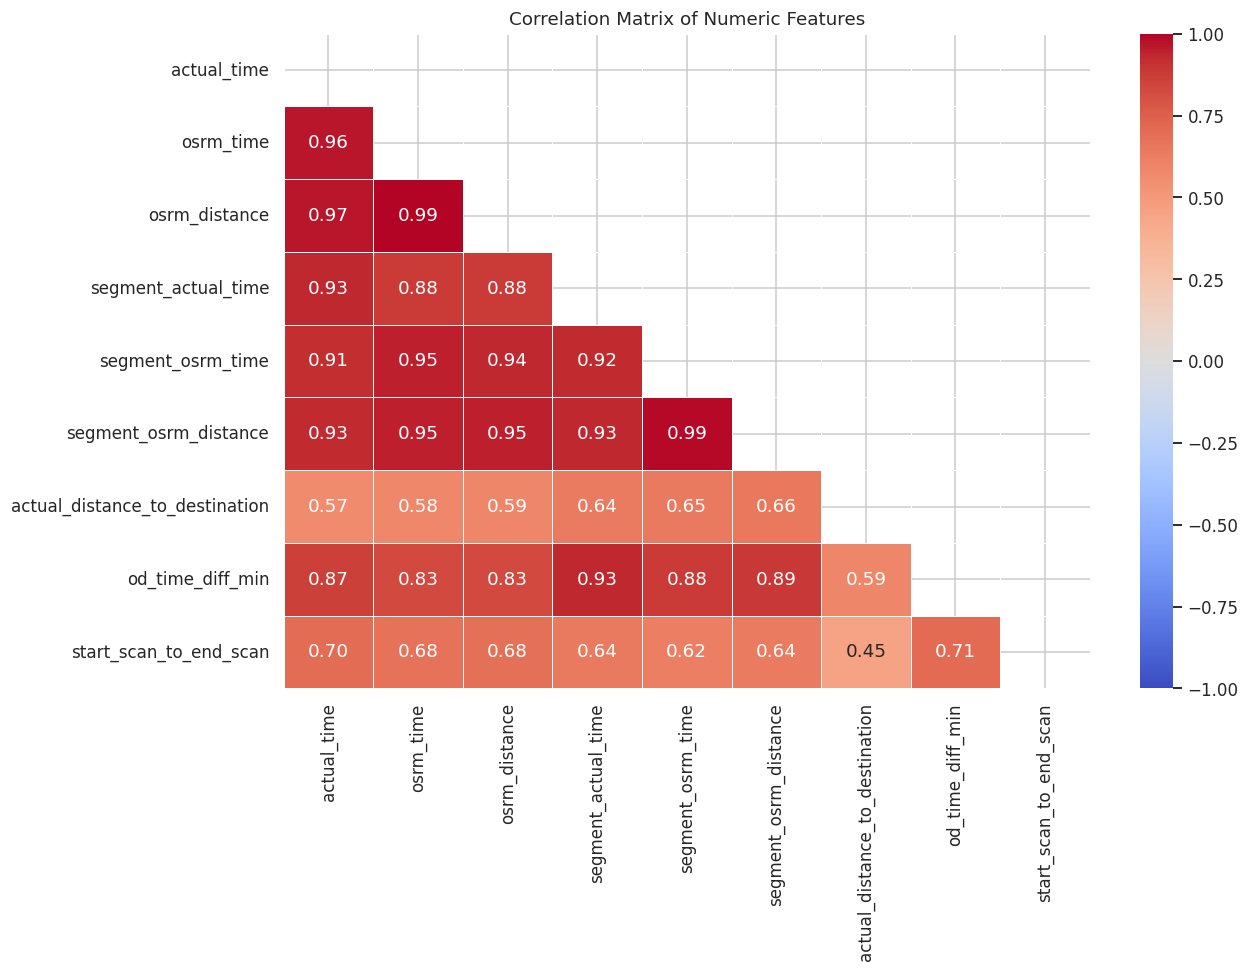

In [26]:
corr = df_clean[num_features].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

## 10. One-Hot Encoding of Categorical Variables

In [27]:
# Convert back to string before dummies
df_clean['route_type'] = df_clean['route_type'].astype(str)
df_clean['is_cutoff']  = df_clean['is_cutoff'].astype(str)
df_clean['trip_weekday'] = df_clean['trip_weekday'].astype(str)

df_encoded = pd.get_dummies(
    df_clean,
    columns=['route_type', 'is_cutoff', 'trip_weekday'],
    drop_first=True
)

print('Shape after encoding:', df_encoded.shape)
ohe_cols = [c for c in df_encoded.columns if any(c.startswith(p) for p in ['route_type_', 'is_cutoff_', 'trip_weekday_'])]
print('New one-hot columns:', ohe_cols)

Shape after encoding: (2292, 29)
New one-hot columns: ['route_type_FTL', 'is_cutoff_True', 'trip_weekday_Monday', 'trip_weekday_Saturday', 'trip_weekday_Sunday', 'trip_weekday_Thursday', 'trip_weekday_Tuesday', 'trip_weekday_Wednesday']


## 11. Normalization & Standardization

In [28]:
scale_cols = num_features  # the 9 numeric columns we treated for outliers

# ── MinMax Scaler ─────────────────────────────────────────────────────────────
mm_scaler = MinMaxScaler()
df_minmax = df_encoded.copy()
df_minmax[scale_cols] = mm_scaler.fit_transform(df_encoded[scale_cols])

# ── Standard Scaler ───────────────────────────────────────────────────────────
std_scaler = StandardScaler()
df_standard = df_encoded.copy()
df_standard[scale_cols] = std_scaler.fit_transform(df_encoded[scale_cols])

print('MinMax scaled range:')
print(df_minmax[scale_cols].describe().loc[['min','max']].round(3))

print('\nStandard scaled stats:')
print(df_standard[scale_cols].describe().loc[['mean','std']].round(3))

MinMax scaled range:
     actual_time  osrm_time  osrm_distance  segment_actual_time  \
min        0.000      0.000          0.000                0.000   
max        1.000      1.000          1.000                1.000   

     segment_osrm_time  segment_osrm_distance  actual_distance_to_destination  \
min              0.000                  0.000                           0.000   
max              1.000                  1.000                           1.000   

     od_time_diff_min  start_scan_to_end_scan  
min             0.000                   0.000  
max             1.000                   1.000  

Standard scaled stats:
      actual_time  osrm_time  osrm_distance  segment_actual_time  \
mean        0.000      0.000         -0.000               -0.000   
std         1.000      1.000          1.000                1.000   

      segment_osrm_time  segment_osrm_distance  \
mean              0.000                  0.000   
std               1.000                  1.000   

      act

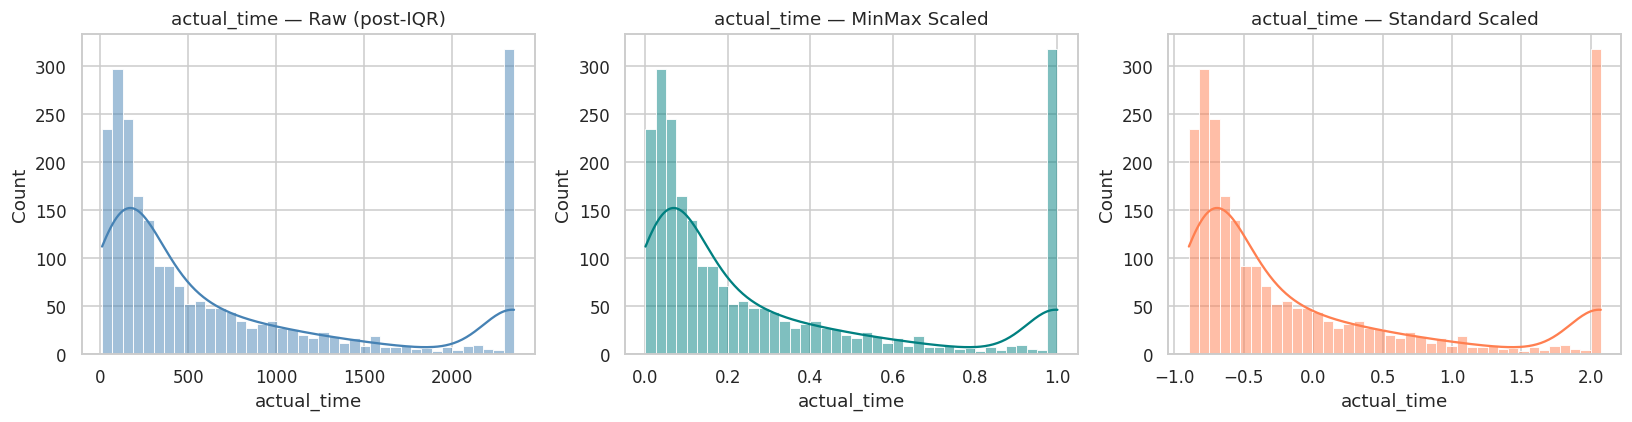

In [29]:
# Compare before/after distributions for one key column
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_clean['actual_time'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('actual_time — Raw (post-IQR)')

sns.histplot(df_minmax['actual_time'], bins=40, kde=True, ax=axes[1], color='teal')
axes[1].set_title('actual_time — MinMax Scaled')

sns.histplot(df_standard['actual_time'], bins=40, kde=True, ax=axes[2], color='coral')
axes[2].set_title('actual_time — Standard Scaled')

plt.tight_layout()
plt.show()

## 12. Business Insights

In [30]:
print('=== TOP SOURCE STATES ===')
print(df_trip['src_state'].value_counts().head(10).to_string())

print('\n=== TOP DESTINATION STATES ===')
print(df_trip['dest_state'].value_counts().head(10).to_string())

print('\n=== BUSIEST CORRIDORS (Top 10) ===')
print(corridor_stats.to_string())

print('\n=== ROUTE TYPE BREAKDOWN ===')
print(df_trip['route_type'].value_counts().to_string())

print('\n=== AVERAGE FACTOR (actual / OSRM time ratio) ===')
print(f"Mean factor: {df_trip['factor'].mean():.3f}")
print(f"Median factor: {df_trip['factor'].median():.3f}")

=== TOP SOURCE STATES ===
src_state
Maharashtra      423
Karnataka        340
Haryana          297
Tamil Nadu       151
Telangana        120
Gujarat          115
Uttar Pradesh    111
Delhi            110
West Bengal       90
Punjab            86

=== TOP DESTINATION STATES ===
dest_state
Maharashtra      409
Karnataka        352
Haryana          222
Tamil Nadu       152
Uttar Pradesh    129
Gujarat          123
Telangana        123
Punjab            98
Delhi             97
West Bengal       94

=== BUSIEST CORRIDORS (Top 10) ===
                               trip_count  avg_distance  avg_time
corridor                                                         
Maharashtra → Maharashtra             389       682.412  1066.591
Karnataka → Karnataka                 325       239.918   406.609
Tamil Nadu → Tamil Nadu               146       271.717   428.664
Haryana → Haryana                     121       319.950   549.140
Gujarat → Gujarat                     107      1089.638  1525.327
Tel

## 13. Recommendations

Based on the analysis above, here are actionable business recommendations:

1. **Improve OSRM estimates for high-factor routes** — Corridors where actual time consistently exceeds OSRM estimates need better route-time calibration. Working with the mapping team to update traffic assumptions on those routes could cut customer disappointment significantly.

2. **Focus on peak-hour bottlenecks** — Trips created during certain hours show longer delivery times. Staggering dispatch times or pre-positioning vehicles before peak windows could reduce congestion-related delays.

3. **Prioritise high-volume source states** — States generating the most trips are where small efficiency gains multiply across thousands of deliveries. Investing in better sorting infrastructure or partner coverage here will have an outsized impact.

4. **Investigate Carting vs FTL route performance** — If one route type shows a systematically higher factor than the other, that points to scheduling or load-planning issues that could be fixed without major cost.

5. **Flag trips likely to breach cutoff early** — Given that `is_cutoff` is predictable from trip-level features (distance, hour, corridor), a simple threshold model could alert dispatchers *before* a trip is created, rather than after it's already running late.

6. **Reduce segment-level time vs total time discrepancy** — If summed segment times don't match recorded actual times, there are logging gaps. Fixing data capture at intermediate scan points will improve future modelling accuracy.

In [31]:
# Save final processed dataset
df_standard.to_csv('delhivery_processed.csv', index=False)
print('Saved: delhivery_processed.csv')
print('Final shape:', df_standard.shape)

Saved: delhivery_processed.csv
Final shape: (2292, 29)
